In [71]:
import numpy as np
from scipy.integrate import odeint,solve_ivp
import matplotlib.pyplot as plt
from functools import partial
import matplotlib
from numpy import exp
import pandas as pd
%matplotlib inline
from ipywidgets import interact
import matplotlib.ticker as ticker

In [2]:
def get5eqsparams(timescale='day'):
    #parameters are from the paper Mathematical modeling of the hypothalamic-pituitary-adrenal gland (HPA) axis, including hippocampal mechanisms.
    #Andersen M1, Vinther F, Ottesen JT.
    
    a1=1/5 #[1/min]
    a2=1/30 #[1/min]
    a3=1/90 #[1/min]

    #mitosis every ** days according to Nolan et al    
    aP=1/15/(60*24)
    
    # turnover of ** days according to Kataoka et al
    aA=1/15/(60*24)

    
    #We normalize all means to 1, we therefore get
    b1=a1;b2=a2;b3=a3;bA=aA;bP=aP;
    
    res=np.array([a1,a2,a3,aA,aP,b1,b2,b3,bA,bP])
    
    if timescale=='hour':
        res=60*res
    elif timescale=='day':
        res=24*60*res
    else:
        raise ValueError('timescale {} is not defined'.format(timescale))
    
    return res


def HPA_model_simulation_o_pituitary_dividing(y,t,timescale='day',u_func = lambda t:1,crh_func = lambda t:1,kgr = lambda t:4,n = lambda t:3):
    '''This function simulates the HPA axis while CRH is the trophic factor
    for pituitary and there is a carrying capacity on the glands'''
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x1_,x2_,x3_,P_,A_]=y
    dy=np.empty(5)
    dy[0]= b1_*(u_func(t)/x3_)*(1/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[1]= b2_*P_*x1_*(1/(1+(x3_/kgr(t))**n(t)))-a2_*x2_ #ACTH
    dy[2]= b3_*x2_*A_-a3_*x3_ #Cortisol
    dy[3]= P_*(bP_*x1_-aP_)#Pituitary cells   
    dy[4]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy

def HPA_model_simulation_o_pituitary_nondividing(y,t,timescale='day',u_func = lambda t:1,crh_func = lambda t:1,kgr = lambda t:4,n = lambda t:3):
    '''This function simulates the HPA axis while CRH is the trophic factor
    for pituitary and there is a carrying capacity on the glands'''
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x1_,x2_,x3_,P_,A_]=y
    dy=np.empty(5)
    dy[0]= b1_*(u_func(t)/x3_)*(1/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[1]= b2_*P_*x1_*(1/(1+(x3_/kgr(t))**n(t)))-a2_*x2_ #ACTH
    dy[2]= b3_*x2_*A_-a3_*x3_ #Cortisol
    dy[3]= 0   
    dy[4]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy


def HPA_model_simulation_o_no_pituitary_old(y,t,timescale='day',u_func = lambda t:1,kgr = lambda t:4, n = lambda t:3):
    '''This function simulates the HPA axis while CRH is the trophic factor
    for pituitary and there is a carrying capacity on the glands'''
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x1_,x3_,A_]=y
    dy=np.empty(3)
    dy[0]= b1_*(1/x3_)*(u_func(t)/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[1]= b3_*x1_*A_-a3_*x3_ #Cortisol
    dy[2]= A_*(bA_*x1_-aA_)#Adrenal cells
    return dy


In [3]:
###############

In [4]:
#ADRENAL ADENOMA: 04/05/23

In [5]:
def get5eqsparams(timescale='day'):
    #parameters are from the paper Mathematical modeling of the hypothalamic-pituitary-adrenal gland (HPA) axis, including hippocampal mechanisms.
    #Andersen M1, Vinther F, Ottesen JT.
    
    a1=1/5 #[1/min]
    a2=1/30 #[1/min]
    a3=1/90 #[1/min]

    #mitosis every 63 days according to Nolan et al    
    aP=1/60/(60*24)
    
    # turnover of 60 days according to Kataoka et al
    aA=1/60/(60*24)

    
    #We normalize all means to 1, we therefore get
    #b1=a1;b2=a2;b3=a3;bA=aA;bP=aP;
    
    res=np.array([a1,a2,a3,aA,aP])
    
    if timescale=='hour':
        res=60*res
    elif timescale=='day':
        res=24*60*res
    else:
        raise ValueError('timescale {} is not defined'.format(timescale))
    
    return res


def adrenal_adenoma_gr(y,t,beta,r_=1,n_=3,timescale='day',u_func = lambda t:1):
    '''This function simulates the HPA axis while CRH is the trophic factor
    for pituitary and there is a carrying capacity on the glands'''
    [a1_,a2_,a3_,aA_,aP_]=get5eqsparams(timescale)
    [x1_,x2_,x3_,P_,A_,C_]=y
    dy=np.empty(6)
    dy[0]= a1_*(u_func(t)/(x3_+x3_**(1+n_)) - x1_) #CRH
    dy[1]= a2_*(x1_*P_/(1+x3_**n_) - x2_) #ACTH
    dy[2]= a3_*(x2_*A_ + C_*beta - x3_) #cortisol
    dy[3]= aP_*(x1_ - 1)*P_ #pituitary cells
    dy[4]= aA_*(x2_-1)*A_ #adrenal cells
    dy[5]= r_*(C_-1)*C_ #adrenal adenoma cells
    return dy

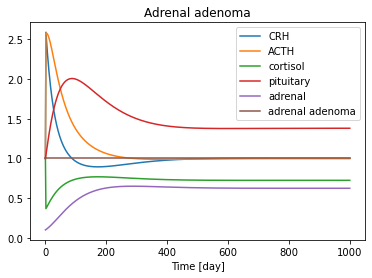

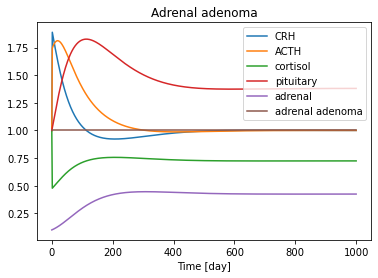

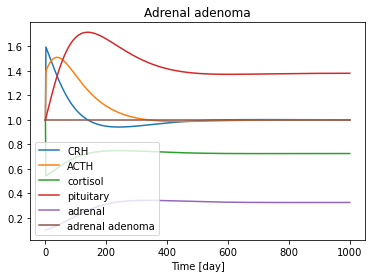

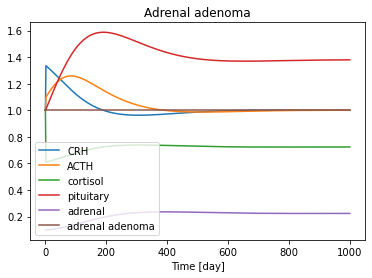

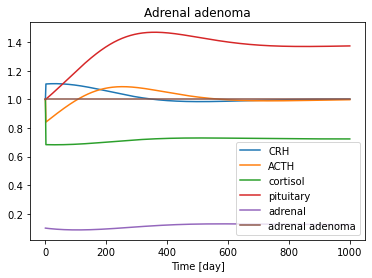

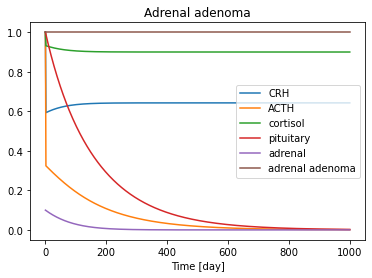

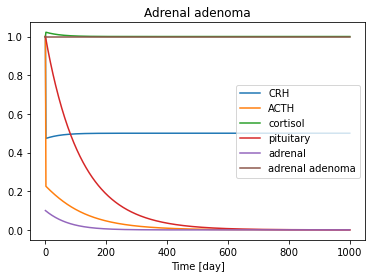

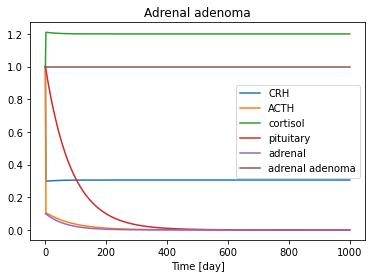

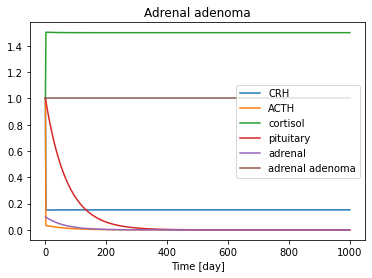

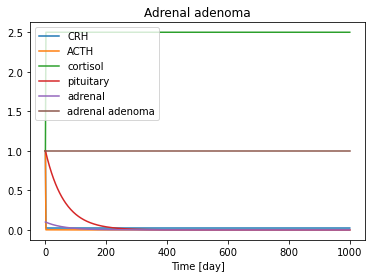

In [6]:
list_of_df_adrenal_adenoma = []
i=0
for bt in [0.1,0.3,0.4,0.5,0.6,0.9,1,1.2,1.5,2.5]:
    int_conditions_adrenal=[1,1,1,1,0.1,1]
    t_tumor=np.linspace(0, 1000, 600)
    plt.figure()
    sol_adrenal_tumor_progression=odeint(lambda y,t: adrenal_adenoma_gr(y,t,beta = bt,timescale='day'),int_conditions_adrenal,t_tumor)
    steady_state_adrenal = sol_adrenal_tumor_progression[-1,:]
    adrenal_adenoma_df = pd.DataFrame({'beta':bt, 'CRH':steady_state_adrenal[0], 'ACTH':steady_state_adrenal[1],
                                         'cortisol':steady_state_adrenal[2], 'pituitary':steady_state_adrenal[3], 
                                         'adrenal':steady_state_adrenal[4], 'adrenal_adenoma':steady_state_adrenal[5]}, index=pd.Index([i]))
    list_of_df_adrenal_adenoma.append(adrenal_adenoma_df)
    plt.plot(t_tumor,sol_adrenal_tumor_progression)
    plt.legend(['CRH','ACTH','cortisol','pituitary','adrenal','adrenal adenoma'])
    plt.xlabel('Time [day]')
    plt.title('Adrenal adenoma')
    i=i+1
adrenal_adenoma_df=pd.concat(list_of_df_adrenal_adenoma)

In [7]:
adrenal_adenoma_df

,beta,CRH,ACTH,cortisol,pituitary,adrenal,adrenal_adenoma
0,0.1,1.000042,1.000047e+00,0.724475,1.380259e+00,6.244460e-01,1.0
1,0.3,1.000066,1.000141e+00,0.724466,1.380340e+00,4.244062e-01,1.0
2,0.4,1.000124,1.000293e+00,0.724443,1.380433e+00,3.243476e-01,1.0
3,0.5,1.000436,1.000667e+00,0.724319,1.380325e+00,2.241696e-01,1.0
4,0.6,1.001681,9.982287e-01,0.723826,1.374477e+00,1.240455e-01,1.0
5,0.9,0.642632,9.167492e-04,0.900000,2.466205e-03,1.531298e-08,1.0
6,1.0,0.500000,5.880507e-05,1.000000,2.351798e-04,9.376285e-09,1.0
7,1.2,0.305474,1.048616e-06,1.200000,9.362072e-06,6.899875e-09,1.0
8,1.5,0.152381,2.582797e-08,1.500000,7.413270e-07,6.265431e-09,1.0
9,2.5,0.024060,1.286170e-10,2.500000,8.884120e-08,5.991212e-09,1.0


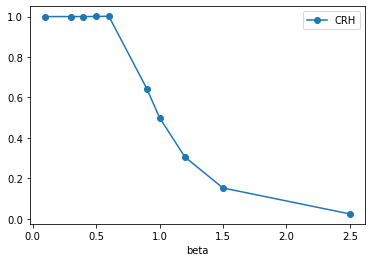

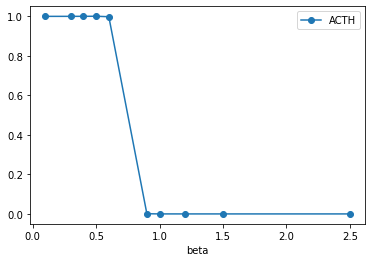

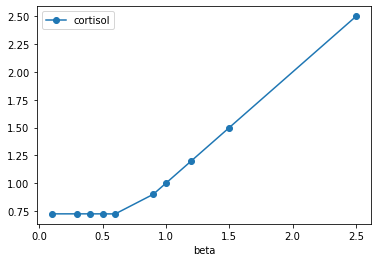

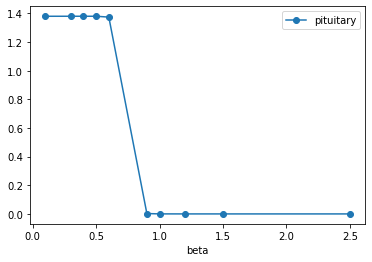

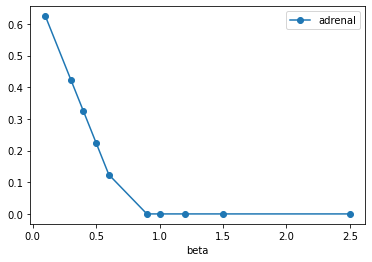

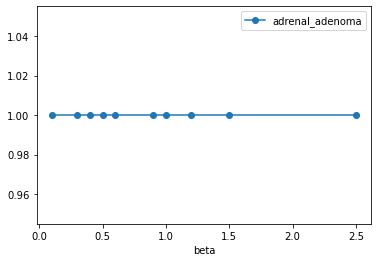

In [8]:
for col in adrenal_adenoma_df.columns:
    if col != 'beta':
        adrenal_adenoma_df.plot(x='beta', y=col, marker='o')
        #plt.ylim(-0.5,4)

In [11]:
#simulation of the above graphs with lines for the analytical solution:

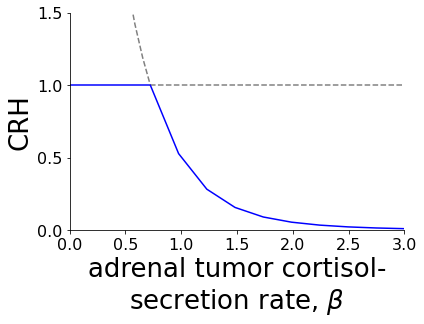

In [12]:
#plt.figure(figsize=(10,8))
x1=adrenal_adenoma_df['beta']
y1=adrenal_adenoma_df['CRH']
#plt.scatter(x1,y1,marker='o',color='blue',s=40)
x2=np.linspace(0,0.724,10)
y2=np.array([0*x+1 for x in x2])
plt.plot(x2,y2,color='blue')
x3=np.linspace(0.724,3,10)
y3=np.array([0*x+1 for x in x3])
plt.plot(x3,y3,'--',color='grey')
x4=np.linspace(0.1,0.724,10)
y4=np.array([1/(beta+beta**4) for beta in x4])
plt.plot(x4,y4,'--',color='grey')
x5=np.linspace(0.724,3,10)
y5=np.array([(1/(beta+beta**4)) for beta in x5])
plt.plot(x5,y5,color='blue')
#plt.title('Adrenal adenoma')
plt.xlabel('adrenal tumor cortisol-\nsecretion rate, $\\beta$',fontsize=26)
plt.ylabel('CRH',fontsize=26)
plt.xlim(0,3)
plt.ylim(0,1.5)
#plt.legend(bbox_to_anchor =(1.8, 1))
#plt.rcParams['axes.linewidth'] = 2
#plt.tick_params(width=2)
plt.xticks([0,0.5,1,1.5,2,2.5,3],fontsize=16)
plt.yticks([0,0.5,1,1.5],fontsize=16)

plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.savefig("adrenal tumor crh.svg", transparent=True)

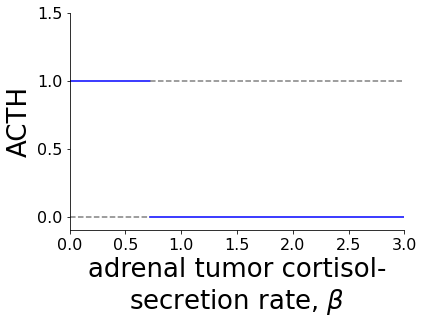

In [20]:
x1=adrenal_adenoma_df['beta']
y1=adrenal_adenoma_df['ACTH']
#plt.scatter(x1,y1,marker='o',color='blue',s=40)
x2=np.linspace(0,0.724,10)
y2=np.array([0*x+1 for x in x2])
plt.plot(x2,y2,color='blue',linewidth='1.5')
x3=np.linspace(0.724,3,10)
y3=np.array([0*x+1 for x in x3])
plt.plot(x3,y3,'--',color='grey',linewidth='1.5')
x4=np.linspace(0,0.724,10)
y4=np.array([0*x for x in x4])
plt.plot(x4,y4,'--',color='grey',linewidth='1.5')
x5=np.linspace(0.724,3,10)
y5=np.array([0*x for x in x5])
plt.plot(x5,y5,color='blue',linewidth='1.5')
#plt.title('Adrenal adenoma')
plt.xlabel('adrenal tumor cortisol-\nsecretion rate, $\\beta$',fontsize=26)
plt.ylabel('ACTH',fontsize=26)
plt.xlim(0,3)
plt.ylim(-0.1,1.2)
#plt.legend(bbox_to_anchor =(1.8, 1))
#plt.rcParams['axes.linewidth'] = 2
#plt.tick_params(width=2)
plt.xticks([0,0.5,1,1.5,2,2.5,3],fontsize=16)
plt.yticks([0,0.5,1,1.5],fontsize=16)
plt.savefig("adrenal tumor acth.svg", transparent=True)

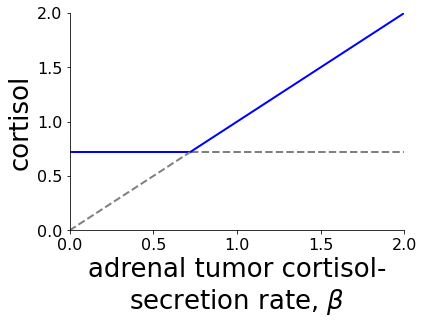

In [22]:
x1=adrenal_adenoma_df['beta']
y1=adrenal_adenoma_df['cortisol']
#plt.scatter(x1,y1,marker='o',color='blue',s=40)
x2=np.linspace(0,0.724,10)
y2=np.array([0*x+0.724 for x in x2])
plt.plot(x2,y2,color='blue',linewidth='2')
x3=np.linspace(0.724,3,10)
y3=np.array([0*x+0.724 for x in x3])
plt.plot(x3,y3,'--',color='grey',linewidth='2')
x4=np.linspace(0,0.724,10)
y4=np.array([beta for beta in x4])
plt.plot(x4,y4,'--',color='grey',linewidth='2')
x5=np.linspace(0.724,3,10)
y5=np.array([beta for beta in x5])
plt.plot(x5,y5,color='blue',linewidth='2')
#plt.title('Adrenal adenoma')
plt.xlabel('adrenal tumor cortisol-\nsecretion rate, $\\beta$',fontsize=26)
plt.ylabel('cortisol',fontsize=26)
plt.xlim(0,2)
plt.ylim(0,2)
#plt.legend(bbox_to_anchor =(1.8, 1))
#plt.rcParams['axes.linewidth'] = 2
#plt.tick_params(width=2)
plt.xticks([0,0.5,1,1.5,2],fontsize=16)
plt.yticks([0,0.5,1,1.5,2],fontsize=16)
plt.savefig("adrenal tumor cort.svg", transparent=True)

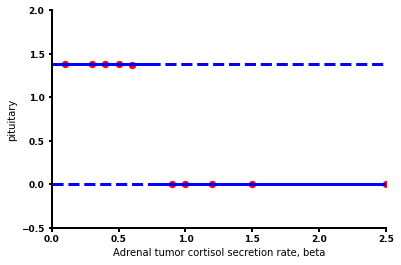

In [34]:
x1=adrenal_adenoma_df['beta']
y1=adrenal_adenoma_df['pituitary']
plt.scatter(x1,y1,marker='o',color='red',s=40)
x2=np.linspace(0,0.724,10)
y2=np.array([0*x+1.38 for x in x2])
plt.plot(x2,y2,color='blue',linewidth='3')
x3=np.linspace(0.724,2.5,10)
y3=np.array([0*x+1.38 for x in x3])
plt.plot(x3,y3,'--',color='blue',linewidth='3')
x4=np.linspace(0,0.724,10)
y4=np.array([0*x for x in x4])
plt.plot(x4,y4,'--',color='blue',linewidth='3')
x5=np.linspace(0.724,2.5,10)
y5=np.array([0*x for x in x5])
plt.plot(x5,y5,color='blue',linewidth='3')
#plt.title('Adrenal adenoma')
plt.xlabel('Adrenal tumor cortisol secretion rate, beta')
plt.ylabel('pituitary')
plt.xlim(0,2.5)
plt.ylim(-0.5,2)
#plt.legend(bbox_to_anchor =(1.8, 1))
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9,fontweight='bold')
plt.yticks(fontsize=9,fontweight='bold')
plt.savefig("adrenal tumor cort.pdf", transparent=True)

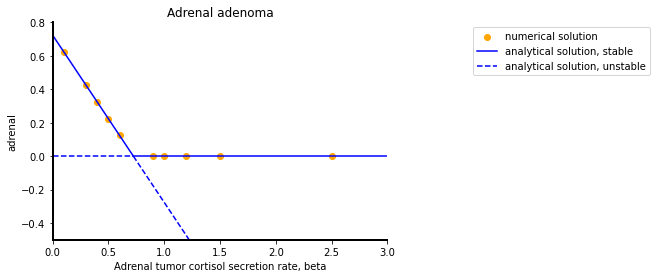

In [35]:
x1=adrenal_adenoma_df['beta']
y1=adrenal_adenoma_df['adrenal']
plt.scatter(x1,y1,marker='o',color='orange',label='numerical solution')
x2=np.linspace(0.724,3,10)
y2=np.array([0*x for x in x2])
plt.plot(x2,y2,color='blue',label='analytical solution, stable')
x3=np.linspace(0,0.724,10)
y3=np.array([0*x for x in x3])
plt.plot(x3,y3,'--',color='blue',label='analytical solution, unstable')
x4=np.linspace(0,0.724,10)
y4=np.array([(0.724-beta) for beta in x4])
plt.plot(x4,y4,color='blue')
x5=np.linspace(0.724,3,10)
y5=np.array([(0.724-beta) for beta in x5])
plt.plot(x5,y5,'--',color='blue')
plt.title('Adrenal adenoma')
plt.xlabel('Adrenal tumor cortisol secretion rate, beta')
plt.ylabel('adrenal')
plt.xlim(0,3)
plt.ylim(-0.5,0.8)
plt.legend(bbox_to_anchor =(1.8, 1))

In [19]:
#Pituitary adenoma 08/05/23

In [47]:
def get5eqsparams(timescale='day'):
    #parameters are from the paper Mathematical modeling of the hypothalamic-pituitary-adrenal gland (HPA) axis, including hippocampal mechanisms.
    #Andersen M1, Vinther F, Ottesen JT.
    
    a1=1/5 #[1/min]
    a2=1/30 #[1/min]
    a3=1/90 #[1/min]

    #mitosis every 63 days according to Nolan et al    
    aP=1/60/(60*24)
    
    # turnover of 60 days according to Kataoka et al
    aA=1/60/(60*24)

    
    #We normalize all means to 1, we therefore get
    #b1=a1;b2=a2;b3=a3;bA=aA;bP=aP;
    
    res=np.array([a1,a2,a3,aA,aP])
    
    if timescale=='hour':
        res=60*res
    elif timescale=='day':
        res=24*60*res
    else:
        raise ValueError('timescale {} is not defined'.format(timescale))
    
    return res


def pituitary_adenoma_gr(y,t,eta,gamma=0.1,r_=1,n_=3,timescale='day',u_func = lambda t:1):
    '''This function simulates the HPA axis while CRH is the trophic factor
    for pituitary and there is a carrying capacity on the glands'''
    [a1_,a2_,a3_,aA_,aP_]=get5eqsparams(timescale)
    [x1_,x2_,x3_,P_,A_,M_]=y
    dy=np.empty(6)
    dy[0]= a1_*(u_func(t)/(x3_+x3_**(1+n_)) - x1_) #CRH
    dy[1]= a2_*((x1_*P_)/(1+x3_**n_) + (eta*M_)/(1+gamma*x3_)- x2_) #ACTH
    dy[2]= a3_*(x2_*A_ -x3_) #cortisol
    dy[3]= aP_*(x1_ - 1)*P_ #pituitary cells
    dy[4]= aA_*(x2_-1)*A_ #adrenal cells
    dy[5]= r_*(1-M_)*M_ #adrenal adenoma cells
    return dy

Text(0.5, 1.0, 'Pituitary adenoma')

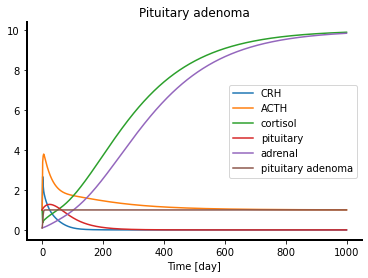

In [48]:
int_conditions=[1,1,1,1,0.1,0.1]
t_tumor=np.linspace(0, 1000, 600)
#plt.plot(t_recovery,[stress_input(x) for x in t_recovery])
#plt.legend(['u'])
plt.figure()
sol_pituitary_tumor_progression=odeint(lambda y,t: pituitary_adenoma_gr(y,t,eta = 2,timescale='day'),int_conditions,t_tumor)
plt.plot(t_tumor,sol_pituitary_tumor_progression)
plt.legend(['CRH','ACTH','cortisol','pituitary','adrenal','pituitary adenoma'])
plt.xlabel('Time [day]')
plt.title('Pituitary adenoma')

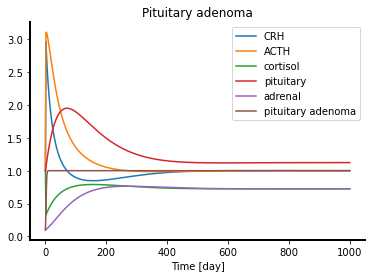

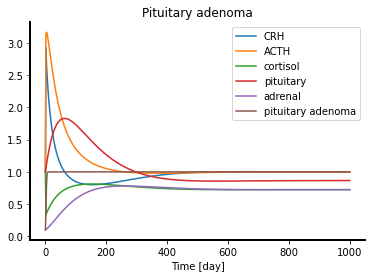

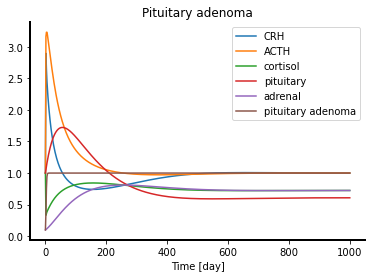

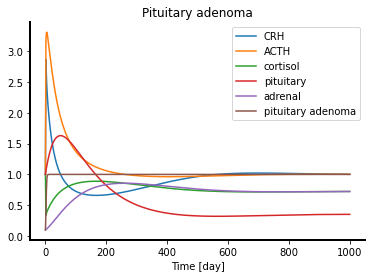

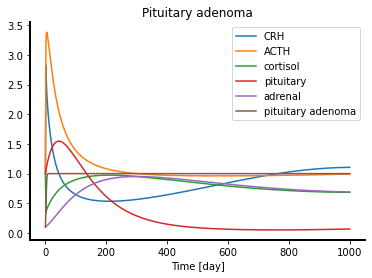

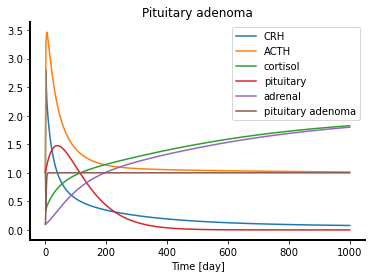

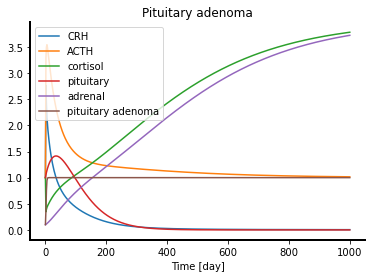

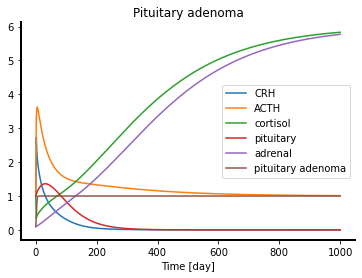

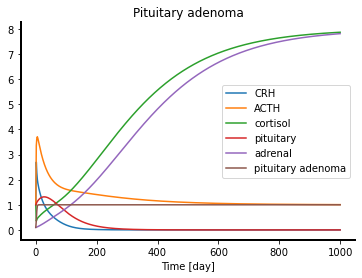

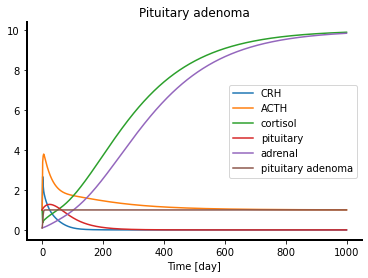

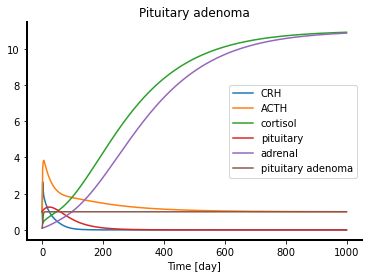

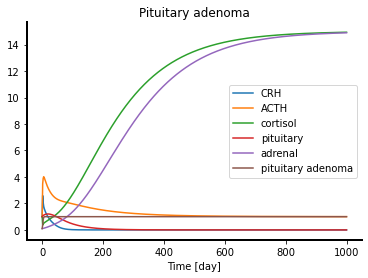

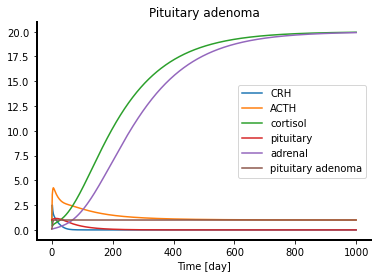

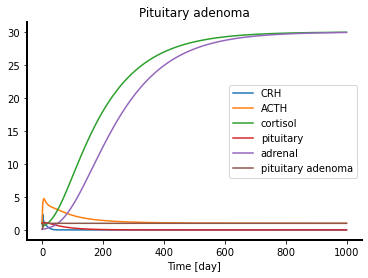

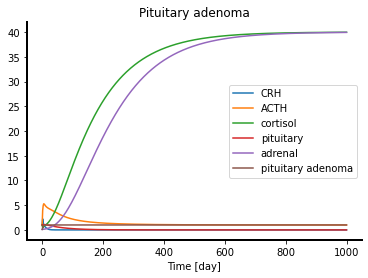

In [49]:
for al in [0.2,0.4,0.6,0.8,1,1.2,1.4,1.6,1.8,2,2.1,2.5,3,4,5]:
    int_conditions=[1,1,1,1,0.1,0.1]
    t_tumor=np.linspace(0, 1000, 600)
    plt.figure()
    sol_pituitary_tumor_progression=odeint(lambda y,t: pituitary_adenoma_gr(y,t,eta = al,timescale='day'),int_conditions,t_tumor)
    plt.plot(t_tumor,sol_pituitary_tumor_progression)
    plt.legend(['CRH','ACTH','cortisol','pituitary','adrenal','pituitary adenoma'])
    plt.xlabel('Time [day]')
    plt.title('Pituitary adenoma')

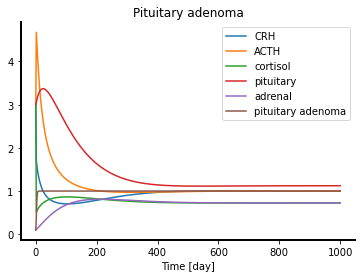

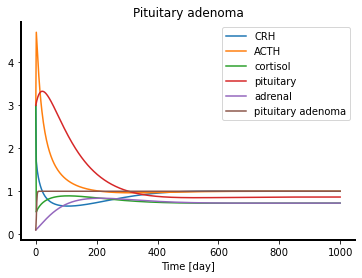

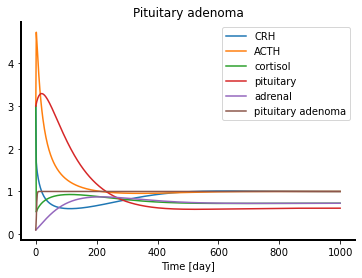

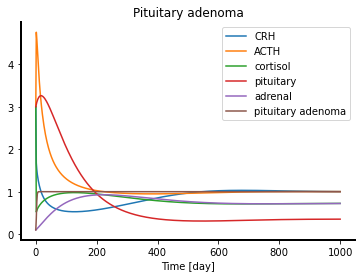

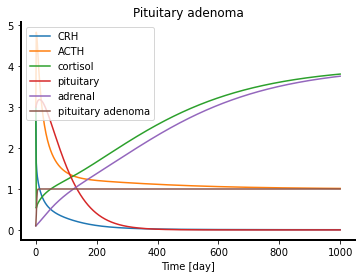

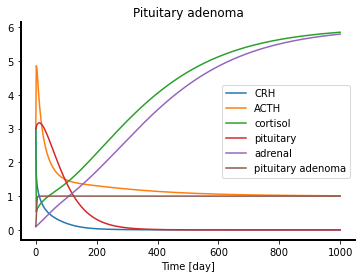

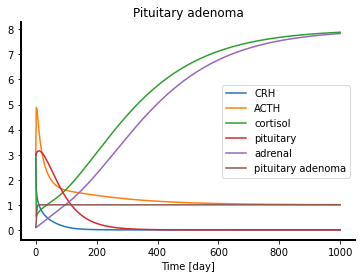

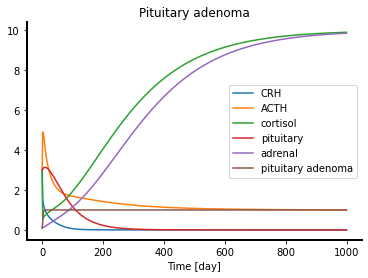

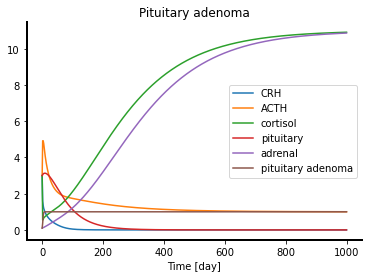

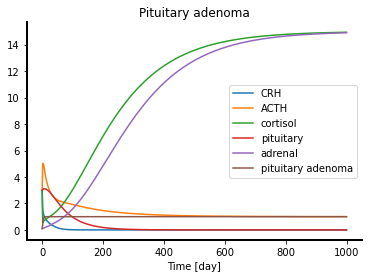

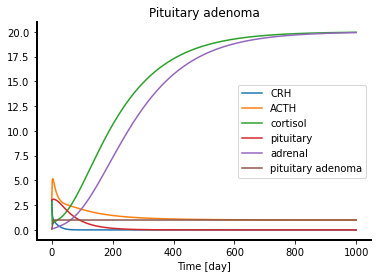

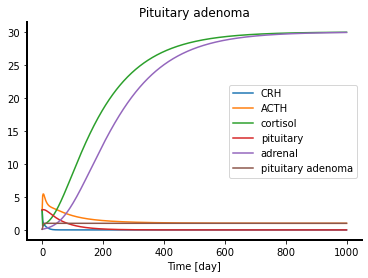

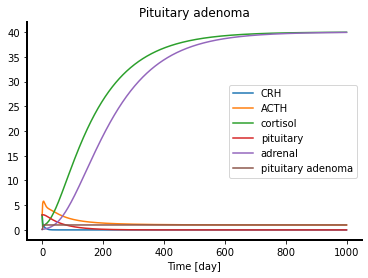

In [50]:
list_of_df = []
i=0
for al in [0.2,0.4,0.6,0.8,1.4,1.6,1.8,2,2.1,2.5,3,4,5]:
    int_conditions=[3,3,3,3,0.1,0.1]
    t_tumor=np.linspace(0, 1000, 600)
    plt.figure()
    sol_pituitary_tumor_progression=odeint(lambda y,t: pituitary_adenoma_gr(y,t,eta = al,timescale='day'),int_conditions,t_tumor)
    steady_state = sol_pituitary_tumor_progression[-1,:]
    pituitary_adenoma_df = pd.DataFrame({'eta':al, 'CRH':steady_state[0], 'ACTH':steady_state[1],
                                         'cortisol':steady_state[2], 'pituitary':steady_state[3], 
                                         'adrenal':steady_state[4], 'pituitary_adenoma':steady_state[5]}, index=pd.Index([i]))
    list_of_df.append(pituitary_adenoma_df)
    plt.plot(t_tumor,sol_pituitary_tumor_progression)
    plt.legend(['CRH','ACTH','cortisol','pituitary','adrenal','pituitary adenoma'])
    plt.xlabel('Time [day]')
    plt.title('Pituitary adenoma')
    i=i+1
pituitary_adenoma_df=pd.concat(list_of_df)

In [51]:
pituitary_adenoma_df

,eta,CRH,ACTH,cortisol,pituitary,adrenal,pituitary_adenoma
0,0.2,1.000040e+00,1.000085,0.724476,1.122924e+00,0.724414,1.0
1,0.4,1.000033e+00,1.000180,0.724479,8.656714e-01,0.724348,1.0
2,0.6,9.999895e-01,1.000502,0.724496,6.087602e-01,0.724133,1.0
3,0.8,1.001237e+00,1.002410,0.724002,3.532951e-01,0.722262,1.0
4,1.4,4.670678e-03,1.013900,3.808086,8.335010e-07,3.755923,1.0
5,1.6,8.501408e-04,1.009524,5.849062,5.291233e-07,5.793921,1.0
6,1.8,2.583874e-04,1.006523,7.883351,4.251989e-07,7.832294,1.0
7,2.0,1.037332e-04,1.004710,9.906244,3.691198e-07,9.859832,1.0
8,2.1,7.041007e-05,1.004084,10.914602,3.509043e-07,10.870242,1.0
9,2.5,2.008838e-05,1.002571,14.935893,2.982169e-07,14.897614,1.0


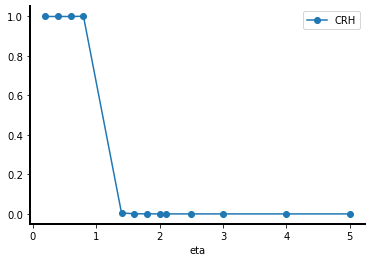

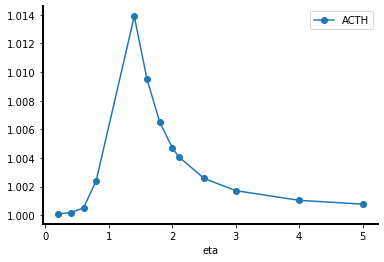

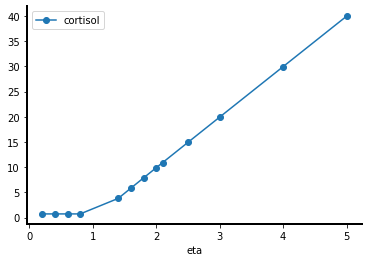

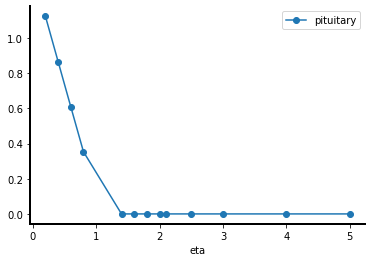

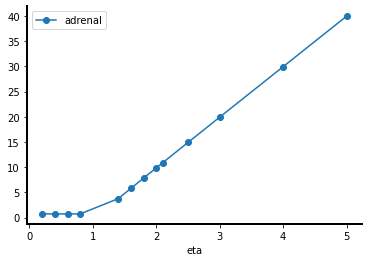

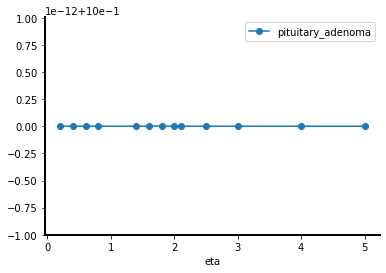

In [52]:
for col in pituitary_adenoma_df.columns:
    if col != 'eta':
        pituitary_adenoma_df.plot(x='eta', y=col,marker='o')

In [53]:
#simulation of the above graphs with lines for the analytical solution:

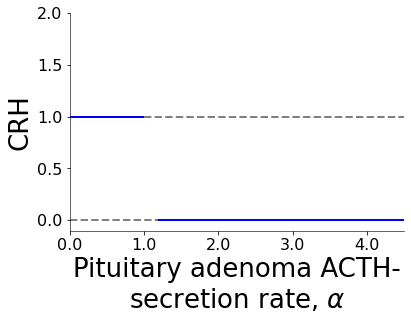

In [75]:
x1=pituitary_adenoma_df['eta']
y1=pituitary_adenoma_df['CRH']
#plt.scatter(x1,y1,marker='o',color='blue',s=40)
x2=np.linspace(0,1,10)
y2=np.array([0*x+1 for x in x2])
plt.plot(x2,y2,color='blue',linewidth='2')
x3=np.linspace(1,4.5,10)
y3=np.array([0*x+1 for x in x3])
plt.plot(x3,y3,'--',color='grey',linewidth='2')
x4=np.linspace(0,1.2,10)
y4=np.array([0*x for x in x4])
plt.plot(x4,y4,'--',color='grey',linewidth='2')
x5=np.linspace(1.2,4.5,10)
y5=np.array([0*x for x in x5])
plt.plot(x5,y5,color='blue',linewidth='2')
#plt.title('Pituitary adenoma')
plt.xlabel('Pituitary adenoma ACTH-\nsecretion rate, $\\alpha$',fontsize=26)
plt.ylabel('CRH',fontsize=26)
plt.xlim(0,4.5)
plt.ylim(-0.1,1.5)
#plt.legend(bbox_to_anchor =(1.8, 1))
plt.rcParams['axes.linewidth'] = 0.6
#plt.tick_params(width=2)
plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
plt.xticks([0.0,1.0,2.0,3.0,4.0],fontsize=16)
plt.yticks([0,0.5,1,1.5,2.0],fontsize=16)
plt.savefig("pituitary adenoma crh.svg", transparent=True)

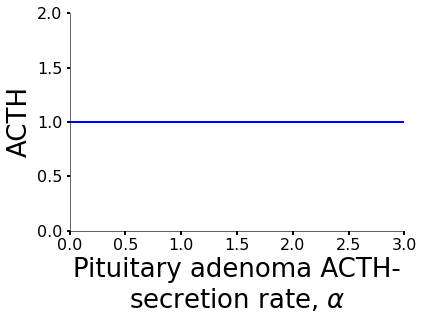

In [96]:
x1=pituitary_adenoma_df['eta']
y1=pituitary_adenoma_df['ACTH']
#plt.scatter(x1,y1,marker='o',color='blue',s=40)
x2=np.linspace(0,4,10)
y2=np.array([0*x+1 for x in x2])
plt.plot(x2,y2,color='blue',linewidth='2')
#plt.title('Pituitary adenoma')
plt.xlabel('Pituitary adenoma ACTH-\nsecretion rate, $\\alpha$',fontsize=26)
plt.ylabel('ACTH',fontsize=26)
plt.xlim(0,3)
plt.ylim(0,2)
#plt.legend(bbox_to_anchor =(1.8, 1))
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks([0,0.5,1,1.5,2,2.5,3],fontsize=16)
plt.yticks([0,0.5,1,1.5,2],fontsize=16)
plt.rcParams['axes.linewidth'] = 0.6
plt.savefig("pituitary adenoma acth.svg", transparent=True)

In [104]:
def format_func(value, tick_number):
    return "{:.1f}".format(value)

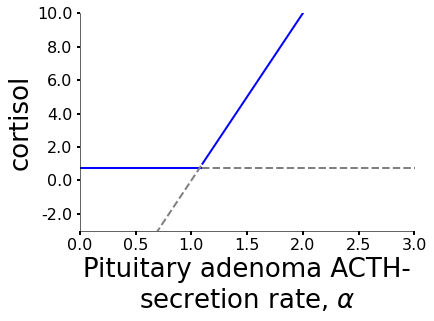

In [108]:
x1=pituitary_adenoma_df['eta']
y1=pituitary_adenoma_df['cortisol']
#plt.scatter(x1,y1,marker='o',color='blue',s=40)
x2=np.linspace(0,1.1,10)
y2=np.array([0*x+0.724 for x in x2])
plt.plot(x2,y2,color='blue',linewidth='2')
x3=np.linspace(1.1,4.5,10)
y3=np.array([0*x+0.724 for x in x3])
plt.plot(x3,y3,'--',color='grey',linewidth='2')
x5=np.linspace(0,1.1,10)
y5=np.array([(eta-1)/0.1 for eta in x5])
plt.plot(x5,y5,'--',color='grey',linewidth='2')
x6=np.linspace(1.1,4.5,10)
y6=np.array([(eta-1)/0.1 for eta in x6])
plt.plot(x6,y6,color='blue',linewidth='2')
#plt.title('Pituitary adenoma')
plt.xlabel('Pituitary adenoma ACTH-\nsecretion rate, $\\alpha$',fontsize=26)
plt.ylabel('cortisol',fontsize=26)
plt.xlim(0,3)
plt.ylim(-3,10)
#plt.legend(bbox_to_anchor =(1.8, 1))
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=16)
plt.yticks([-2.0,0.0,2.0,4.0,6.0,8.0,10.0],fontsize=16)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_func))
plt.rcParams['axes.linewidth'] = 0.6
plt.savefig("pituitary adenoma cortisol.svg", transparent=True)

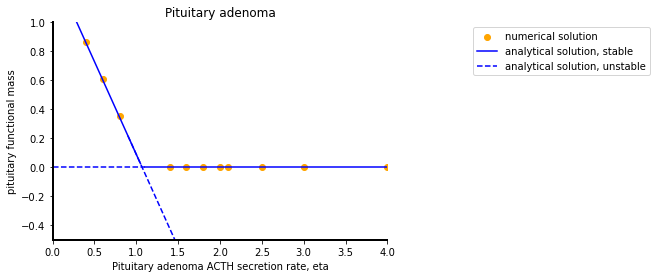

In [26]:
x1=pituitary_adenoma_df['eta']
y1=pituitary_adenoma_df['pituitary']
plt.scatter(x1,y1,marker='o',color='orange',label='numerical solution')
x2=np.linspace(0,1.05,10)
y2=np.array([1.37*(1-(eta/1.07)) for eta in x2])
plt.plot(x2,y2,color='blue',label='analytical solution, stable')
x3=np.linspace(0.9,4,10)
y3=np.array([1.37*(1-(eta/1.07)) for eta in x3])
plt.plot(x3,y3,'--',color='blue',label='analytical solution, unstable')
x4=np.linspace(0,1.1,10)
y4=np.array([0*x for x in x4])
plt.plot(x4,y4,'--',color='blue')
x5=np.linspace(1.1,4,10)
y5=np.array([0*x for x in x5])
plt.plot(x5,y5,color='blue')
plt.title('Pituitary adenoma')
plt.xlabel('Pituitary adenoma ACTH secretion rate, eta')
plt.ylabel('pituitary functional mass')
plt.xlim(0,4)
plt.ylim(-0.5,1)
plt.legend(bbox_to_anchor =(1.8, 1))

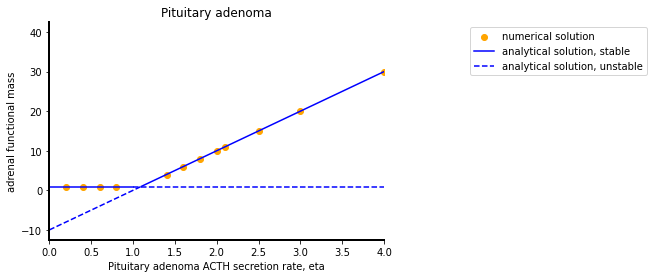

In [143]:
x1=pituitary_adenoma_df['eta']
y1=pituitary_adenoma_df['adrenal']
plt.scatter(x1,y1,marker='o',color='orange',label='numerical solution')
x2=np.linspace(0,1,10)
y2=np.array([0*x+0.724 for x in x2])
plt.plot(x2,y2,color='blue',label='analytical solution, stable')
x3=np.linspace(1,4,10)
y3=np.array([0*x+0.724 for x in x3])
plt.plot(x3,y3,'--',color='blue',label='analytical solution, unstable')
#x4=np.linspace(0,1,10)
#y4=np.array([(x-1)/beta for x in x4])
#plt.plot(x4,y4,'--',color='orange')
x4=np.linspace(0,1.1,10)
y4=np.array([(eta-1)/0.1 for eta in x4])
plt.plot(x4,y4,'--',color='blue')
x5=np.linspace(1.1,4,10)
y5=np.array([(eta-1)/0.1 for eta in x5])
plt.plot(x5,y5,color='blue')
plt.title('Pituitary adenoma')
plt.xlabel('Pituitary adenoma ACTH secretion rate, eta')
plt.ylabel('adrenal functional mass')
plt.xlim(0,4)
plt.legend(bbox_to_anchor =(1.8, 1))